# Wildfire Model Interpretation and Error Analysis

This notebook evaluates the final wildfire classification model through interpretability and failure analysis techniques. The goal is to better understand which environmental and temporal factors drive wildfire predictions, where the model struggles, and what limitations or biases may exist in the dataset.

## 1. Imports and Paths

In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Sklearn
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import joblib
import shap

# Preprocessing module (one folder up)
sys.path.insert(0, "..")
from Preprocessing import load_and_split

# ── Paths ────────────────────────────────────────────────────────────────
DATA_PATH   = Path("..") / "data" / "FW_Veg_Rem_Combined.csv"
OUTPUTS_DIR = Path("..") / "outputs"

BEST_MODEL_PATH = OUTPUTS_DIR / "best_model_rf.pkl"

print("All imports OK")

All imports OK


## 2. Load Dataset and Best Model

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = load_and_split(DATA_PATH)

best_model = joblib.load(BEST_MODEL_PATH)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nBest model loaded successfully.")

Split  →  train: 38,756  |  val: 8,305  |  test: 8,306
Class distribution (train):
fire_size_class
B    0.660
C    0.195
G    0.072
F    0.036
D    0.025
E    0.013
Name: proportion, dtype: float64

Train shape: (38756, 25)
Validation shape: (8305, 25)
Test shape: (8306, 25)

Best model loaded successfully.


## 3. Generate Predictions

In [4]:
y_pred_encoded = best_model.predict(X_test)

# Decode labels if predictions are numeric
if np.issubdtype(np.array(y_pred_encoded).dtype, np.number):
    y_pred = label_encoder.inverse_transform(y_pred_encoded)
else:
    y_pred = y_pred_encoded

y_test_values = np.array(y_test)

print(classification_report(y_test_values, y_pred, zero_division=0))

              precision    recall  f1-score   support

           B       0.77      0.82      0.80      5479
           C       0.34      0.27      0.30      1622
           D       0.05      0.03      0.04       209
           E       0.09      0.08      0.08       105
           F       0.29      0.24      0.26       295
           G       0.63      0.82      0.71       596

    accuracy                           0.66      8306
   macro avg       0.36      0.38      0.37      8306
weighted avg       0.64      0.66      0.65      8306



## 4. Confusion Matrix Analysis


In [5]:
labels = sorted(np.unique(y_test_values))

cm = confusion_matrix(
    y_test_values,
    y_pred,
    labels=labels
)

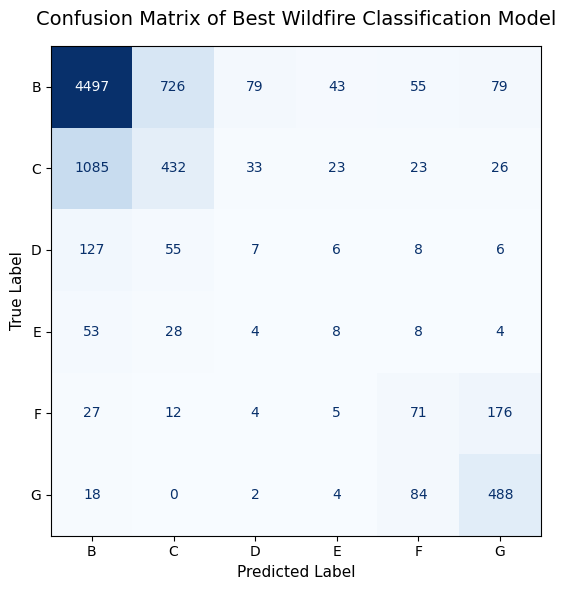

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Confusion Matrix of Best Wildfire Classification Model",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

## show plot
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the model performs best on the smaller and more common wildfire classes, especially Class B. Since those fires appear much more frequently in the dataset, the model has more examples to learn from and tends to predict them more confidently.

A noticeable pattern is that many Class C, D, and E fires are predicted as lower-severity classes, especially Class B. This suggests the model struggles to separate medium and larger fires from smaller ones when the environmental conditions look similar. The most concerning errors are the false negatives in Classes F and G, where the model underestimates higher-risk fires as smaller categories.

Overall, the matrix suggests that the model captures general wildfire behavior reasonably well, but still struggles with rarer extreme wildfire events due to class imbalance in the dataset.

## 5. False Negatives

This section identifies the largest underestimations of wildfire made by the model.

In [7]:
results_df = X_test.copy()

results_df["Actual"] = y_test_values
results_df["Predicted"] = y_pred

class_order = {label: i for i, label in enumerate(sorted(labels))}

results_df["Actual_Order"] = results_df["Actual"].map(class_order)
results_df["Predicted_Order"] = results_df["Predicted"].map(class_order)

false_negatives = results_df[
    results_df["Predicted_Order"] < results_df["Actual_Order"]
].copy()

false_negatives["Miss_Severity"] = (
    false_negatives["Actual_Order"] - false_negatives["Predicted_Order"]
)

print("Total false negatives:", len(false_negatives))
false_negatives[["Actual", "Predicted", "Miss_Severity"]].head()

Total false negatives: 1508


,Actual,Predicted,Miss_Severity
50984,G,F,1
18539,E,B,3
30898,C,B,1
28804,C,B,1
37441,D,B,2


### False Negative Interpretation

The model produced 1,508 false negatives, meaning it predicted these fires as smaller or less severe than they actually were. A lot of the mistakes involve fires getting pushed down into Class B, even when the real fire was much larger. Some misses are more extreme than others. One example shows a Class E fire being predicted as Class B, which is a pretty significant gap. This makes it seem like the model struggles when a fire does not match the more common wildfire patterns it saw during training.

Overall, the model seems to do well with typical wildfire conditions, but has a harder time recognizing rarer or more unusual high-severity fires.

### False Negatives by Actual Fire Class

To better understand where the model underestimates severity, I grouped false negatives by their true wildfire class. This makes it easier to see whether missed fires are concentrated in the larger and rarer classes.

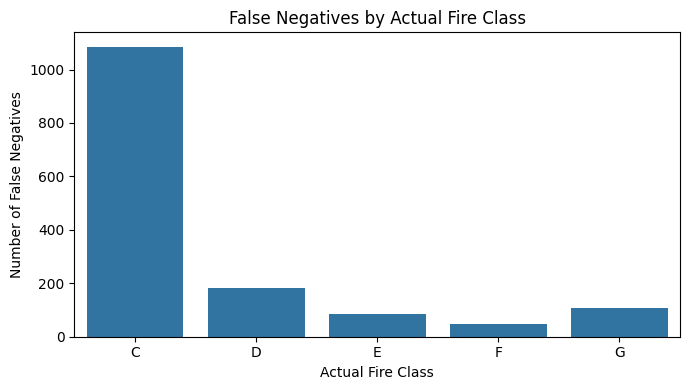

In [9]:
fn_by_class = (
    false_negatives["Actual"]
    .value_counts()
    .sort_index()
    .reset_index()
)

fn_by_class.columns = ["Actual_Class", "False_Negative_Count"]

fn_by_class

plt.figure(figsize=(7, 4))

sns.barplot(
    data=fn_by_class,
    x="Actual_Class",
    y="False_Negative_Count"
)

plt.title("False Negatives by Actual Fire Class")
plt.xlabel("Actual Fire Class")
plt.ylabel("Number of False Negatives")

plt.tight_layout()
plt.show()

This chart makes the model’s weaknesses easier to see. Most false negatives come from Class C fires, suggesting the model struggles to separate smaller fires from medium-sized ones and often pushes them into lower categories like Class B.

The number of false negatives decreases for larger wildfire classes, but that is likely because Classes F and G appear less often in the dataset overall. Even with fewer mistakes, those misses are still the most concerning since some extreme fires were underestimated as very low-severity classes.

## 6. Misclassified Case Studies

This section looks at a few specific wildfire examples where the model underestimated fire severity. The goal is to better understand why these mistakes may have happened and whether there are patterns behind the model’s failures.

In [8]:
severe_misses = false_negatives.sort_values(
    by="Miss_Severity",
    ascending=False
)

case_studies = severe_misses.head(5)

case_studies[
    ["Actual", "Predicted", "Miss_Severity"]
]

,Actual,Predicted,Miss_Severity
50264,G,B,5
26988,G,B,5
49075,G,B,5
52062,G,B,5
49270,G,B,5


### Selected Failure Case Interpretation

What stands out here is how aggressively the model underestimated these fires. Every one of the largest misses was predicted as Class B, even though the actual fires were Class G. That suggests the model is relying heavily on the most common wildfire patterns it learned during training.

It also points to a limitation in the dataset itself. The model mainly sees weather, seasonal, and location-based features, but wildfire severity can also depend on things that are harder to capture, like terrain, fuel conditions, or containment response. Since Class G fires are much rarer in the data, the model struggles more with these extreme cases and tends to default toward safer, more common predictions.

## 7. SHAP Feature Importance

This section uses SHAP values to better understand how the model makes predictions and which features have the largest influence on wildfire classification. Because SHAP calculations can be computationally expensive, a smaller sample of the test set is used to keep the analysis manageable.

In [18]:
X_shap = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

## extract final estimator if model is a pipeline
if hasattr(best_model, "named_steps"):

    final_model = list(best_model.named_steps.values())[-1]

    preprocessing_steps = list(best_model.named_steps.values())[:-1]

    X_shap_transformed = X_shap.copy()

    for step in preprocessing_steps:
        if hasattr(step, "transform"):
            X_shap_transformed = step.transform(X_shap_transformed)

else:
    final_model = best_model
    X_shap_transformed = X_shap

print(type(final_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [27]:
# manual transformed feature names based on Preprocessing.py

weather_base = [
    "Temp_pre_30", "Temp_pre_15", "Temp_pre_7", "Temp_cont",
    "Wind_pre_30", "Wind_pre_15", "Wind_pre_7", "Wind_cont",
    "Hum_pre_30", "Hum_pre_15", "Hum_pre_7", "Hum_cont",
    "Prec_pre_30", "Prec_pre_15", "Prec_pre_7", "Prec_cont",
]

weather_trends = []
for var in ["Temp", "Wind", "Hum", "Prec"]:
    weather_trends += [f"{var}_trend_30_7", f"{var}_trend_15_7"]

continuous_names = ["latitude", "longitude", "remoteness"]

categorical_names = list(
    best_model.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["ohe"]
    .get_feature_names_out(["stat_cause_descr", "state"])
)

month_names = ["discovery_month"]

vegetation_names = list(
    best_model.named_steps["preprocessor"]
    .named_transformers_["vegetation"]
    .named_steps["ohe"]
    .get_feature_names_out(["Vegetation"])
)

year_names = ["disc_pre_year"]

date_names = [
    "month_num", "day_of_year",
    "month_sin", "month_cos",
    "doy_sin", "doy_cos"
]

feature_names = (
    weather_base
    + weather_trends
    + continuous_names
    + categorical_names
    + month_names
    + vegetation_names
    + year_names
    + date_names
)

print("Feature names:", len(feature_names))
print("Transformed columns:", X_shap_transformed.shape[1])

Feature names: 106
Transformed columns: 106


In [28]:
# convert transformed SHAP data into dataframe with feature names
X_shap_named = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names
)

print(X_shap_named.shape)
X_shap_named.head()

(500, 106)


,Temp_pre_30,Temp_pre_15,Temp_pre_7,Temp_cont,Wind_pre_30,Wind_pre_15,Wind_pre_7,Wind_cont,Hum_pre_30,Hum_pre_15,...,Vegetation_14,Vegetation_15,Vegetation_16,disc_pre_year,month_num,day_of_year,month_sin,month_cos,doy_sin,doy_cos
0,-0.344223,-0.299293,-0.930198,-0.628286,2.514900,1.451703,1.559314,-0.683670,-0.510912,-0.381217,...,0.0,1.0,0.0,-0.114729,10.0,292.0,-0.866025,5.000000e-01,-0.955211,0.295927
1,-0.811970,-0.528077,-0.330516,-0.628286,2.896268,2.721338,3.549644,-0.683670,0.644055,0.138761,...,0.0,1.0,0.0,1.250867,3.0,63.0,1.000000,6.123234e-17,0.882679,0.469977
2,1.370052,1.391132,1.434430,1.013054,-1.435740,-1.266033,-1.058620,-0.245605,1.095362,1.021135,...,0.0,0.0,0.0,1.402600,8.0,221.0,-0.866025,-5.000000e-01,-0.607058,-0.794658
3,1.354021,1.283135,1.250090,0.706254,-0.182881,-0.004627,-0.631935,0.561558,-0.262895,0.064310,...,0.0,0.0,0.0,0.188737,9.0,266.0,-1.000000,-1.836970e-16,-0.989372,-0.145404
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,1.0,0.0,-0.266462,9.0,254.0,-1.000000,-1.836970e-16,-0.938710,-0.344707


In [29]:
## compute values
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_shap_named)

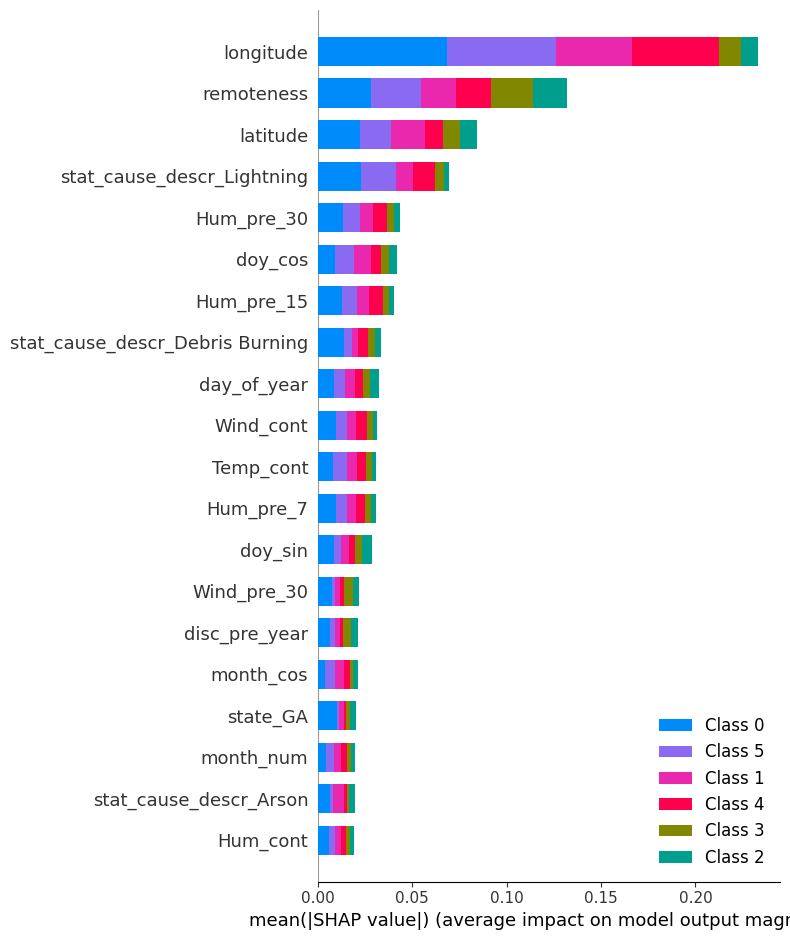

In [30]:
## summary plot 
## bar
shap.summary_plot(
    shap_values,
    X_shap_named,
    plot_type="bar"
)


### SHAP Interpretation

The SHAP summary plot shows that the model is relying on more than just weather. Longitude, remoteness, and latitude are the top three features, which show geography is playing a huge role in how the model classifies wildfire severity. This makes sense because wildfire risk is not evenly distributed across the US. Certain regions likely have more frequent or more severe fires, so the model learns location as a shortcut for risk. Remoteness also stands out, which is interesting because it may connect to response time, detection, or how quickly a fire can be contained.

Weather still matters, but it is not the only story here. Humidity, wind, temperature, and day-of-year features appear throughout the top features, which suggests the model is combining location with environmental conditions and seasonal timing.

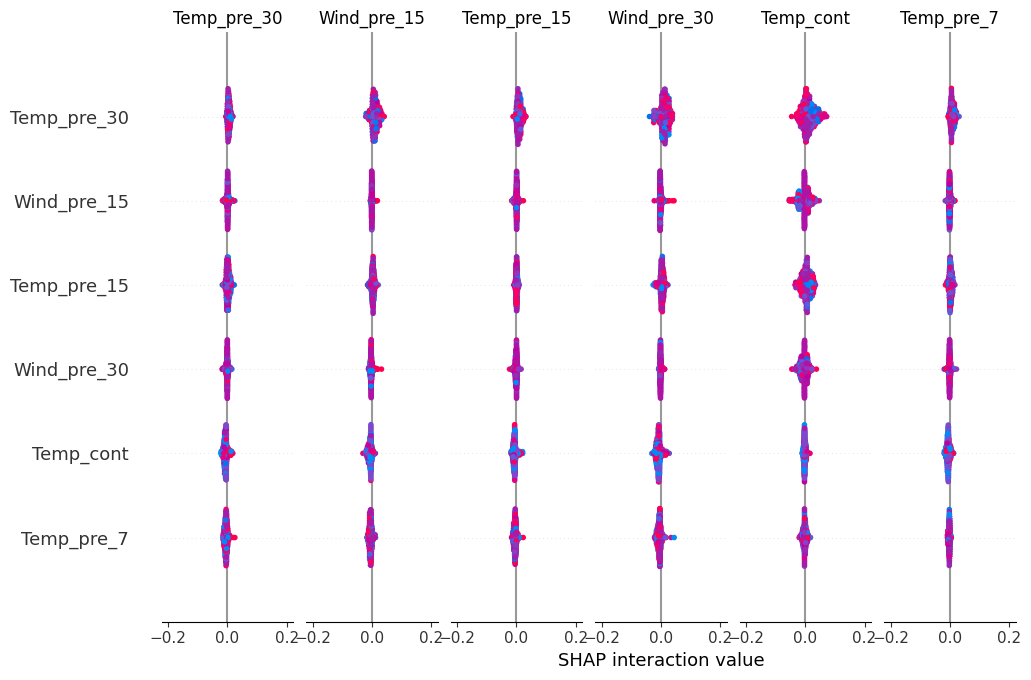

In [31]:
## interaction plot
shap.summary_plot(
    shap_values,
    X_shap_named
)

### SHAP Interaction Plot Interpretation

The SHAP interaction plot shows that temperature and wind-related variables are interacting with each other, but most of the points stay close to zero. This suggests the model is not relying on one huge interaction effect. Instead, it seems to be using several smaller signals together. The strongest interaction patterns appear around temperature before the fire, wind before the fire, and temperature at containment. That fits the wildfire context because hot and windy conditions can make fires spread faster, especially when those conditions build up before discovery. What I take from this plot is that the model is not just looking at one feature in isolation. It is using weather timing and weather combinations, but geography still seems to carry the most overall importance based on the main SHAP summary plot.

### Overall SHAP Takeaway

My main takeaway from SHAP is that this model is very geography-driven. Longitude, latitude, and remoteness matter more than I expected, which suggests the model may be learning regional wildfire patterns very strongly.

This is useful, but it also creates a possible weakness. If a severe fire happens in a location that historically looks lower-risk, the model may underestimate it. That connects back to the false negatives earlier, where some Class G fires were predicted as Class B. The weather features still support the model’s predictions, especially humidity, wind, temperature, and seasonal timing. But overall, the model seems to predict severity through a mix of where the fire happens and what the surrounding weather looks like.

## 8. Dataset Biases and Limitations

One thing that stood out to me throughout this analysis is how much the model depends on the data it was trained on. Since the dataset only includes reported US wildfires, it probably misses smaller or more remote fires that were never fully documented. Because of that, the model may learn wildfire behavior more accurately in areas where fires are reported more consistently.

The class imbalance also affects the predictions a lot. Smaller fires appear much more often in the dataset, so the model naturally becomes more confident predicting those categories. That pattern showed up repeatedly in the confusion matrix, where larger fires were often underestimated as smaller wildfire classes.

There are also important wildfire factors the model never actually sees, like terrain, fuel conditions, vegetation density, or containment response. So even though the model picks up on strong environmental and geographic patterns, it still cannot fully capture how unpredictable wildfire behavior can be.

### Interpreting These Biases

Looking back at the earlier false negatives, a lot of those failures make more sense now. The model performs best when fires match the patterns it saw most often during training. Once a fire becomes more unusual, whether that's because of location, timing, or severity. The predictions become less reliable. 

That is probably why some Class G fires were confidently predicted as Class B. The model learned the dominant wildfire patterns well, but struggled more with rare extreme events that had fewer examples in the dataset.

## 9. Final Interpretation Summary

Overall, the model did a good job capturing the relationship between environmental conditions and wildfire severity. The SHAP analysis showed that weather-related variables like temperature, humidity, and short-term conditions leading up to the fire had the biggest impact on predictions.

At the same time, the confusion matrix and false negative analysis revealed an important weakness: the model consistently struggled more with larger wildfire classes. Instead of spreading mistakes evenly across categories, it often defaulted toward smaller and more common fire classes. That pattern says a lot about both the model and the dataset itself. The model learned the dominant wildfire trends reasonably well, but it still has trouble recognizing rare, high-severity events that fall outside the patterns it saw most often during training.